# Current plotting

C_act_eigvals_layerX_epochYYYY.npy
    scaling of activation covariance eigenvalues (layerwise, per epoch)


rotation_act.csv
    rotation of activations eigenfunctions (layerwise, per epoch)



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os, numpy as np, re, glob
from matplotlib import cm

# Plotting rotation per layer
def plot_rotation_per_layer(run_dir: str, which: str = "act", logx: bool = True, logy: bool = True):
    fname = "rotation_act.csv" if which == "act" else "rotation_bp.csv"
    p = os.path.join(run_dir, "kernel", fname)
    if not os.path.exists(p):
        print(f"[plot_rotation_per_layer] missing {p}")
        return
    df = pd.read_csv(p)
    fig = plt.figure(); ax = fig.add_subplot(111)
    x = df["epoch"].to_numpy()
    x_plot = x + 1 if logx else x  # avoid log(0)
    cols = [c for c in df.columns if c.startswith(f"rho_{which}_layer_")]
    for c in cols:
        y = df[c].to_numpy()
        ax.plot(x_plot, y, label=c)
    if logx: ax.set_xscale("log")
    if logy: ax.set_yscale("log")
    ax.set_xlabel("epoch" + (" (log)" if logx else ""))
    ax.set_ylabel("rotation ρ_k" + (" (log)" if logy else ""))
    ax.legend(ncol=2, fontsize=8)

# Helper function for plotting eigenvalues over epochs per layer
def _epochs_from_summary(run_dir: str) -> np.ndarray:
    path = os.path.join(run_dir, "kernel", "summary.csv")
    if not os.path.exists(path):
        return np.array([], dtype=int)
    df = pd.read_csv(path)
    return df["epoch"].to_numpy(dtype=int)

def _available_layers_from_files(run_dir: str, which: str) -> list[int]:
    """
    which: 'act' -> looks for C_act_eigvals_layer{ell}_epoch*.npy (ell=0..L)
           'bp'  -> looks for C_bp_eigvals_layer{ell}_epoch*.npy  (ell=1..L)
    """
    pat = "C_act_eigvals_layer*_epoch*.npy" if which == "act" else "C_bp_eigvals_layer*_epoch*.npy"
    files = glob.glob(os.path.join(run_dir, "kernel", pat))
    layers = set()
    for f in files:
        m = re.search(r"layer(\d+)_epoch", os.path.basename(f))
        if m: layers.add(int(m.group(1)))
    return sorted(layers)

# Plotting eigenvalues over epochs per layer
def plot_eigenvalues_over_epochs_per_layer(run_dir: str, which: str = "act"):
    epochs = _epochs_from_summary(run_dir)
    if epochs.size == 0:
        print("[plot_eigenvalues_over_epochs_per_layer] no summary.csv to infer epochs")
        return

    layers = _available_layers_from_files(run_dir, which=which)
    if not layers:
        print(f"[plot_eigenvalues_over_epochs_per_layer] no eigenvalue files for which='{which}'")
        return

    for ell in layers:
        vals_list = []
        valid_epochs = []
        for e in epochs:
            fn = f"C_act_eigvals_layer{ell}_epoch{e:04d}.npy" if which == "act" else f"C_bp_eigvals_layer{ell}_epoch{e:04d}.npy"
            p = os.path.join(run_dir, "kernel", fn)
            if os.path.exists(p):
                vals = np.load(p)  # [k_ell]
                vals_list.append(vals)
                valid_epochs.append(e)
        if not vals_list:
            continue

        minK = min(v.shape[0] for v in vals_list)
        Y = np.stack([v[:minK] for v in vals_list], axis=0)  # [E, minK]
        X = np.array(valid_epochs, dtype=int) + 1  # log-safe

        cmap = cm.get_cmap("viridis", minK)
        fig = plt.figure(); ax = fig.add_subplot(111)
        for i in range(minK):
            ax.plot(X, Y[:, i], color=cmap(i), label=f"mode_{i+1}")
        ax.set_xscale("log"); ax.set_yscale("log")
        title_which = "Forward/Activation" if which == "act" else "Backward/Delta"
        ax.set_xlabel("epoch (log)"); ax.set_ylabel("eigenvalue (log)")
        ax.set_title(f"{title_which} top-k eigenvalues — layer {ell}")
        sm = cm.ScalarMappable(cmap=cmap)
        sm.set_array(np.arange(1, minK+1))
        cbar = plt.colorbar(sm, ax=ax, pad=0.01)
        cbar.set_label("mode index")

In [2]:
run_arg = "mnist_example_L4_epochs_100"
run_dir = run_arg if os.path.isdir(run_arg) else os.path.join("results", run_arg)

In [ ]:
plot_eigenvalues_over_epochs_per_layer(run_dir, which='act')

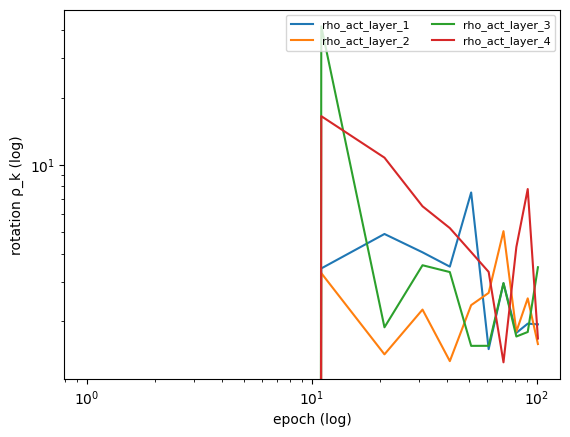

In [4]:
plot_rotation_per_layer(run_dir, which='act', logx=True, logy=True)

### 2nd Version

We note that in MLP the nodes are fully connected with the next and previous layer, so the eigenvalues of each layer can be seen as a clear unique metric of each layer at each training stage.

In [5]:
def _epochs_from_summary(run_dir: str) -> np.ndarray:
    path = os.path.join(run_dir, "kernel", "summary.csv")
    if not os.path.exists(path):
        return np.array([], dtype=int)
    df = pd.read_csv(path)
    return df["epoch"].to_numpy(dtype=int)

def _available_layers_from_files(run_dir: str, which: str) -> list[int]:
    """
    which: 'act' -> looks for C_act_eigvals_layer{ell}_epoch*.npy (ell=0..L)
           'bp'  -> looks for C_bp_eigvals_layer{ell}_epoch*.npy  (ell=1..L)
    """
    pat = "C_act_eigvals_layer*_epoch*.npy" if which == "act" else "C_bp_eigvals_layer*_epoch*.npy"
    files = glob.glob(os.path.join(run_dir, "kernel", pat))
    layers = set()
    for f in files:
        m = re.search(r"layer(\d+)_epoch", os.path.basename(f))
        if m: layers.add(int(m.group(1)))
    return sorted(layers)

def plot_eigenvalues_over_epochs_per_layer_variant(run_dir: str, which: str = "act"):
    epochs = _epochs_from_summary(run_dir)
    if epochs.size == 0:
        print("[plot_eigenvalues_over_epochs_per_layer] no summary.csv to infer epochs")
        return

    layers = _available_layers_from_files(run_dir, which=which)
    if not layers:
        print(f"[plot_eigenvalues_over_epochs_per_layer] no eigenvalue files for which='{which}'")
        return

    # Create the figure for the plots
    fig, ax = plt.subplots(1, 1, figsize=(25,4))
    marks = [0,120,240,360,480]
    for mark, ell in zip(marks, layers):
        vals_list = []
        valid_epochs = []
        for e in epochs:
            fn = f"C_act_eigvals_layer{ell}_epoch{e:04d}.npy" if which == "act" else f"C_bp_eigvals_layer{ell}_epoch{e:04d}.npy"
            p = os.path.join(run_dir, "kernel", fn)
            if os.path.exists(p):
                vals = np.load(p)  # [k_ell]
                vals_list.append(vals)
                valid_epochs.append(e)
        if not vals_list:
            continue

        minK = min(v.shape[0] for v in vals_list)
        Y = np.stack([v[:minK] for v in vals_list], axis=0)  # [E, minK]
        X = np.array(valid_epochs, dtype=int) + 1 + mark# log-safe

        cmap = cm.get_cmap("viridis", minK)
        print(f"Shape of eigenvalue array per layer {Y.shape}")
        for i in range(minK):
            ax.plot(X, Y[:, i], color=cmap(i), label=f"mode_{i+1}")
        # Setting the scale in x and y
        x_scale = 'linear'
        y_scale = 'log'
        ax.set_xscale(x_scale); ax.set_yscale(y_scale)
        title_which = "Forward/Activation" if which == "act" else "Backward/Delta"
        ax.set_xlabel(f"epoch ({x_scale})"); ax.set_ylabel(f"eigenvalue ({y_scale})")
        ax.set_title(f"{title_which} top-k eigenvalues")
        sm = cm.ScalarMappable(cmap=cmap)
        sm.set_array(np.arange(1, minK+1))
        if ell == len(layers)-1:
            cbar = plt.colorbar(sm, ax=ax, pad=0.01)
            cbar.set_label("mode index")
        ax.set_xticks([50,170,290,410,530], labels=['Later 0','Layer 1','Layer 2','Layer 3','Layer 4'])


/tmp/ipykernel_2821407/2147346172.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", minK)
/tmp/ipykernel_2821407/2147346172.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", minK)
/tmp/ipykernel_2821407/2147346172.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", minK)
/tmp/ipykernel_2821407/2147346172.py:52: MatplotlibDeprecationWarning: The get_cmap function was 

Shape of eigenvalue array per layer (11, 15)
Shape of eigenvalue array per layer (11, 15)
Shape of eigenvalue array per layer (11, 15)
Shape of eigenvalue array per layer (11, 15)
Shape of eigenvalue array per layer (11, 15)


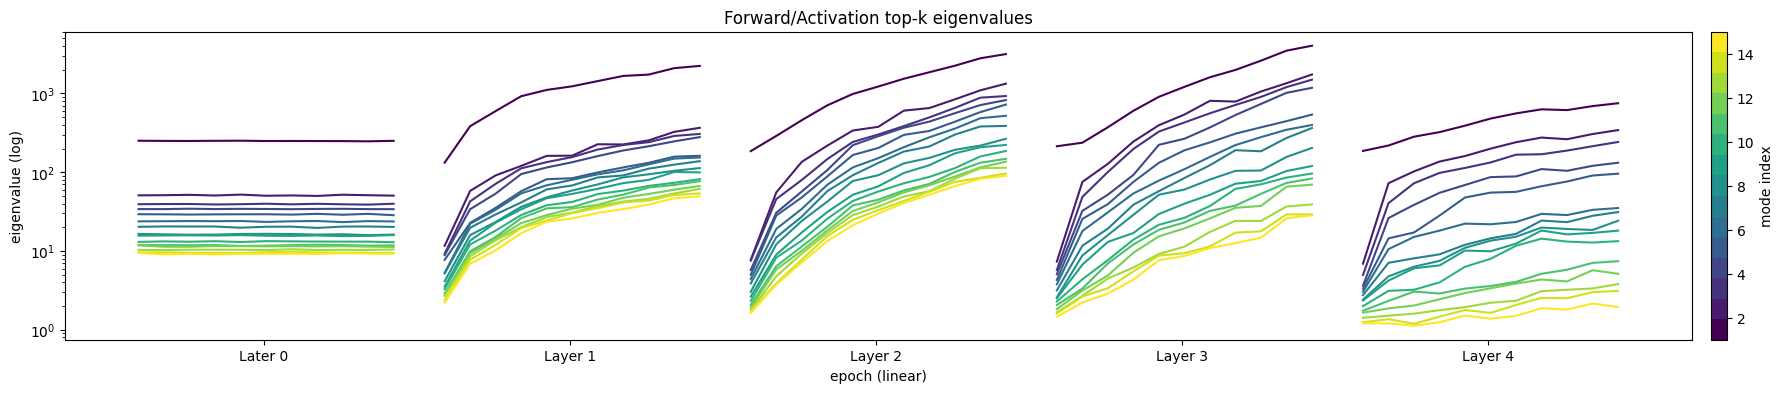

In [6]:
plot_eigenvalues_over_epochs_per_layer_variant(run_dir, which='act')

# MY IDEA

Extract highest rotation value and parametrise w.r.t. that the other rotations, being vectors' length the eigenvalue and vectors' direction the rotation. The plot is divided in layerwise, and for each layer the evolution of the collection of vectors

## Multiple rotating vectors; pending to incorporate the alrady stored scaling and rotating data

In [14]:
import numpy as np, pandas as pd, os, re, glob
import plotly.graph_objects as go
from itertools import chain

# Hyperparameters in visualisation:
#
# np.deg2frad(90): rotations are until 90 degrees max in rodrigues max

# Helper function for plotting eigenvalues over epochs per layer
def _epochs_from_summary(run_dir: str) -> np.ndarray:
    path = os.path.join(run_dir, "kernel", "summary.csv")
    if not os.path.exists(path):
        return np.array([], dtype=int)
    df = pd.read_csv(path)
    return df["epoch"].to_numpy(dtype=int)

def _available_layers_from_files(run_dir: str, which: str) -> list[int]:
    """
    which: 'act' -> looks for C_act_eigvals_layer{ell}_epoch*.npy (ell=0..L)
           'bp'  -> looks for C_bp_eigvals_layer{ell}_epoch*.npy  (ell=1..L)
    """
    pat = "C_act_eigvals_layer*_epoch*.npy" if which == "act" else "C_bp_eigvals_layer*_epoch*.npy"
    files = glob.glob(os.path.join(run_dir, "kernel", pat))
    layers = set()
    for f in files:
        m = re.search(r"layer(\d+)_epoch", os.path.basename(f))
        if m: layers.add(int(m.group(1)))
    return sorted(layers)

# Function for rotating a vector v around an axis by angle theta using Rodrigues' rotation formula
def rodrigues_rotate(v: np.ndarray, axis: np.ndarray, t: float) -> np.ndarray:
    """
    Rotate vector v around 'axis' by angle theta (radians) using Rodrigues' formula.
    axis must be a unit vector.

    We parametrise the rotations such that the highest rotation is 90 degrees, and the other are scaled accordingly by t
    t is a parameter [0,1] --> th/max_rot for th in layer_r_rotations
    So to get theta in radians we do:
    theta = np.deg2rad(90) *t

    """
    theta = np.deg2rad(90) *t
    k = axis / np.linalg.norm(axis)
    v_rot = (v * np.cos(theta) +
             np.cross(k, v) * np.sin(theta) +
             k * (k @ v) * (1 - np.cos(theta)))
    return v_rot

# Plotting multiple vectors with same axes but different origins
def multi_vectors_same_axes(initial_vectors,axes,n_epochs,scales=None, rot_values=None, origins=None,colors=None,
                            trail=True,trail_len=None,return_fig=False, plot_details=None, epoch_counting=None,
                            log_scale=False):
    """
    plot_details = {
        'max_eigenvalue': max_eig,
        'min_eigenvalue': min_eig,
        'max_rotation': max_rot,
        'min_rotation': min_rot,
    }
    """
    num = len(initial_vectors)
    if len(axes) != num:
        raise ValueError("initial_vectors and axes must have same length")

    # ---- NEW: origins handling ----
    if origins is None:
        origins = [(0.0, 0.0, 0.0)] * num
    if len(origins) != num:
        raise ValueError("origins must have same length as vectors")

    origins = np.array([np.asarray(o, dtype=float) for o in origins])  # (num, 3)

    # (everything up to vector computation stays the same)
    init_vs = np.array([np.asarray(v, dtype=float) for v in initial_vectors])
    axes_arr = np.array([np.asarray(a, dtype=float) for a in axes])
    axes_arr = np.array([a / np.linalg.norm(a) for a in axes_arr])

    if colors is None:
        palette = ["#636EFA", "#EF553B", "#00CC96"]
        colors = [palette[i % len(palette)] for i in range(num)]

    # SCALING
    scales_mat = np.ones((num, n_epochs))
    if scales is not None:
        for i, s in enumerate(scales):
            scales_mat[i] = s if np.isscalar(s) else np.asarray(s)

    # ROTATING
    max_rot = plot_details['max_rotation']
    vectors_per_layer = int(len(axes)/len(rot_values))
    base_vectors_new = []
    for i in range(len(rot_values)):
        layer_i_rotations = rot_values[i]
        # We parametrise the rotations such that the highest rotation is 90 degrees, and the other are scaled accordingly
        # the parameter passed to rodrigues_rotate is [0,1]
        layer_i_base_vectors = np.stack([rodrigues_rotate(init_vs[0], axes_arr[0], th/max_rot) for th in layer_i_rotations])
        base_vectors_new.append([layer_i_base_vectors for _ in range(vectors_per_layer)]) # NEED TO CONVERT THIS TO LIST OF LISTS NOT list of arrrays
    base_vectors_new = np.stack(base_vectors_new).reshape(num, n_epochs, 3)

    vectors_new = base_vectors_new * scales_mat[:, :, None] # so both have same shape: (60, 11, 3)

    # axis limits now consider origins too
    all_points = np.concatenate([
        origins[:, None, :] + vectors_new,
        origins[:, None, :]
    ], axis=1).reshape(-1, 3)
    lim = max(1.0, np.max(np.abs(all_points)) * 1.1)

    # ---- INITIAL TRACES ----
    fig = go.Figure()
    for i in range(num):
        o = origins[i]
        v0 = vectors_new[i, 0]
        p0 = o + v0

        fig.add_trace(go.Scatter3d(
            x=[o[0], p0[0]], y=[o[1], p0[1]], z=[o[2], p0[2]],
            mode="lines+markers",
            line=dict(width=6, color=colors[i]),
            marker=dict(size=3),
            name=f"vec{i+1}"
        ))

        if trail:
            fig.add_trace(go.Scatter3d(
                x=[p0[0]], y=[p0[1]], z=[p0[2]],
                mode="lines",
                line=dict(width=3, color=colors[i]),
                showlegend=False
            ))

        fig.add_trace(go.Scatter3d(
            x=[p0[0]], y=[p0[1]], z=[p0[2]],
            mode="markers",
            marker=dict(size=6, color=colors[i]),
            showlegend=False
        ))

    # ---- FRAMES ----
    frames = []
    for t in range(n_epochs):
        frame_data = []
        for i in range(num):
            o = origins[i]
            v = vectors_new[i, t]
            p = o + v

            frame_data.append(dict(
                type="scatter3d",
                x=[o[0], p[0]], y=[o[1], p[1]], z=[o[2], p[2]],
                mode="lines+markers",
                line=dict(width=6, color=colors[i]),
                marker=dict(size=3)
            ))
            # ---- TRAIL ---- Take it out in case the trails are undesired
            if trail:
                start = 0 if trail_len is None else max(0, t - trail_len + 1)
                pts = origins[i] + vectors_new[i, start:t+1]
                frame_data.append(dict(
                    type="scatter3d",
                    x=pts[:,0].tolist(), y=pts[:,1].tolist(), z=pts[:,2].tolist(),
                    mode="lines",
                    line=dict(width=0, color=colors[i])
                ))

            frame_data.append(dict(
                type="scatter3d",
                x=[p[0]], y=[p[1]], z=[p[2]],
                mode="markers",
                marker=dict(size=6, color=colors[i])
            ))

        frames.append(go.Frame(data=frame_data, name=str(t)))

    fig.frames = frames

    # layout with single shared scene
    n_layers = len(rot_values)
    fig.update_layout(
        title="Eigenvalue scaling and eigenfunction rotation per layer",
        width=1000,
        height=600,
        scene=dict(
            # Custom axis limits. As the length of the vectors is adjusted already to max=10, here we just pick so
            xaxis=dict(range=[-10, 10], title="x (log)", autorange=False),
            yaxis=dict(range=[-10, 10*n_layers], title="y (log)", autorange=False), # y-axis has to have range(-10, 10*)
            zaxis=dict(range=[-10, 10], title="z (log)", autorange=False),
            aspectmode="manual",
            aspectratio=dict(x=1, y=n_layers-1, z=1)
        ),
        updatemenus=[{
            "type":"buttons",
            "buttons":[
                {"label":"Play", "method":"animate", "args":[None, {"epoch": {"duration": 50, "redraw": True}, "fromcurrent": True}]},
                {"label":"Pause", "method":"animate", "args":[[None], {"epoch": {"duration": 0, "redraw": False}, "mode":"immediate"}]}
            ],
            "showactive": True,
            "x": 0.1, "y": 0
        }],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix":"Epoch: "},
            "pad": {"b":10, "t":50},
            "steps": [
                {"args":[[str(k)], {"epoch": {"duration": 0, "redraw": True}, "mode":"immediate"}],
                 "label": str(epoch_counter), "method": "animate"}
                for k,epoch_counter in zip(
                    range(n_epochs), 
                    range(n_epochs) if epoch_counting is None else epoch_counting)
            ]
        }]
    )

    if return_fig:
        return fig
    else:
        fig.show()

# Helper function to distribute points in a grid for multiple layers
def distribute_points_in_grid(N, num_layers):
    points = []
    k = int(np.ceil(np.sqrt(N)))
    spacings_of_vectors = int(np.ceil(np.sqrt(N))) # Spaces of the grid
    grid_number = spacings_of_vectors*2.5/2 # Distance between vectors is 2.5 units and then /2 to adjust grid
    xs = np.linspace(-grid_number, grid_number, k)
    ys = np.linspace(-grid_number, grid_number, k)

    X, Y = np.meshgrid(xs, ys)
    for i in range(num_layers):
        Z = np.zeros_like(X) +10*i
        # A 2D grid embedded in a 3D space
        points = points + np.column_stack([X.ravel(), Z.ravel(), Y.ravel()])[:N].tolist()
    return points

# MAIN FUNCTION TO PLOT ROTATION AND EIGENVALUES PER LAYER
def plot_rotation_and_eigenvalues_per_layer(run_dir: str, which: str = "act", log_scale_eigs: bool = True):
    """
    Rotation data

        It is later parametrised to be in [0,1] for the rodrigues rotation function

    """
    fname = "rotation_act.csv" if which == "act" else "rotation_bp.csv"
    p = os.path.join(run_dir, "kernel", fname)
    if not os.path.exists(p):
        print(f"[plot_rotation_per_layer] missing {p}")
        return
    df = pd.read_csv(p)
    x_plot = df["epoch"].to_numpy()
    cols = [c for c in df.columns if c.startswith(f"rho_{which}_layer_")]
    rotation_values = []  # Rotation values per layer per epoch: structure of 4 elements, each with [num_epochs]
    for c in cols:
        rotation_values.append(df[c].to_numpy())

    """
        Eigenvalues data (scaling)
    """
    epochs = _epochs_from_summary(run_dir)
    if epochs.size == 0:
        print("[plot_eigenvalues_over_epochs_per_layer] no summary.csv to infer epochs")
        return

    layers = _available_layers_from_files(run_dir, which=which)
    if not layers:
        print(f"[plot_eigenvalues_over_epochs_per_layer] no eigenvalue files for which='{which}'")
        return

    Y_all_layers = []
    marks = [0,120,240,360,480]
    for mark, ell in zip(marks, layers):
        vals_list = []
        valid_epochs = []
        for e in epochs:
            fn = f"C_act_eigvals_layer{ell}_epoch{e:04d}.npy" if which == "act" else f"C_bp_eigvals_layer{ell}_epoch{e:04d}.npy"
            p = os.path.join(run_dir, "kernel", fn)
            if os.path.exists(p):
                vals = np.load(p)  # [k_ell]
                vals_list.append(vals)
                valid_epochs.append(e)
        if not vals_list:
            continue

        minK = min(v.shape[0] for v in vals_list)
        Y = np.stack([v[:minK] for v in vals_list], axis=0)  # [E, minK]
        X = np.array(valid_epochs, dtype=int) + 1 + mark# log-safe
        Y_all_layers.append(Y)
        
    # RESHAPING EIGENVALUES DATA
    del Y_all_layers[0] # Remove first layer (input layer) for mathcing data of rotating eigenvectors (it doesnt include input layer)
    n_epochs = len(Y_all_layers[0])  # number of epochs (assumes every layer has the same # epochs)
    flattened_by_epoch = [
        list(chain.from_iterable(layer[e] for layer in Y_all_layers))
        for e in range(n_epochs)
    ]
    # Transpose: each element becomes the list across all epochs for that vector index (log OR linear)
    if log_scale_eigs:
        scaling = [
        [np.log(v) for v in vec_across_epochs]
        for vec_across_epochs in zip(*flattened_by_epoch)
        ]
    else:
        scaling = [list(tup) for tup in zip(*flattened_by_epoch)]

    """
        Maximum eigenvalue and rotation for shaping plot
    """
    # NEXT STEP USE THIS TO PARAMETRISE THE 3D PLOTTING
    max_eig = max(max(s) for s in scaling)
    min_eig = min(min(s) for s in scaling)
    
    max_rot = max(np.max(arr) for arr in rotation_values)
    min_rot = min(np.min(arr) for arr in rotation_values)
    plot_details = {
        'max_eigenvalue': max_eig,
        'min_eigenvalue': min_eig,
        'max_rotation': max_rot,
        'min_rotation': min_rot,
    }
    # Parametrises the length of the vectors given the maximum eigenvalue and a fixed spacing between vectors
    vector_scaling = 1/(1+(max_eig //10))
    """
        Preparing plotting parameters
    """

    # Call plotting
    vectors_per_layer = int(Y.shape[1])
    """
    The number of initial vectors must match the number of vectors in total: #layers * vectors_per_layer
    The axes must match the number of vectors in total too.
    The origins must match the number of layers (each layer's vectors share the same origin).
    """
    # Distribute vectors per layer in a grid
    origins = distribute_points_in_grid(vectors_per_layer, len(Y_all_layers)) # 4*15=60 elements
    # vector_scaling is used to maintain a reasonable size of the vectors in the 3D plot
    initial_vectors = [(0,vector_scaling,0) for _ in range(len(Y_all_layers)*vectors_per_layer)] 
    axes = [(1,0,0) for _ in range(len(Y_all_layers)*vectors_per_layer)] # To ensure rotations are all made against one axis
    n_epochs = len(epochs)

    multi_vectors_same_axes(initial_vectors=initial_vectors, axes=axes, n_epochs=n_epochs, 
                            origins=origins, scales=scaling, rot_values=rotation_values, plot_details=plot_details,
                            epoch_counting=x_plot)

In [15]:
run_arg = "mnist_example_L4_epochs_100"
run_dir = run_arg if os.path.isdir(run_arg) else os.path.join("results", run_arg)
plot_rotation_and_eigenvalues_per_layer(run_dir, which='act', log_scale_eigs=True)